# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from catboost import CatBoostClassifier

df = pd.read_csv("data/interview.csv")

df_clean = df.dropna(how='all')
df_clean = df_clean.dropna(subset=['feature_0'])
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

df_clean = df_clean[df_clean['feature_0'].abs() < 1e8]

df_clean['angle'] = np.arctan2(df_clean['feature_2'], df_clean['feature_3'])

X = df_clean[['feature_0', 'feature_1', 'feature_2', 'feature_3', 'angle']]
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=4,
    verbose=False,
    random_seed=42,
    eval_metric='AUC'
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=30)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== Классификационный отчёт ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

print("\n=== Важность признаков ===")
feature_importance = model.get_feature_importance(prettified=True)
print(feature_importance)


=== Классификационный отчёт ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

ROC-AUC: 1.0000

=== Важность признаков ===
  Feature Id  Importances
0  feature_3    51.673743
1  feature_2    28.381673
2  feature_1    19.944584
3  feature_0     0.000000
4      angle     0.000000


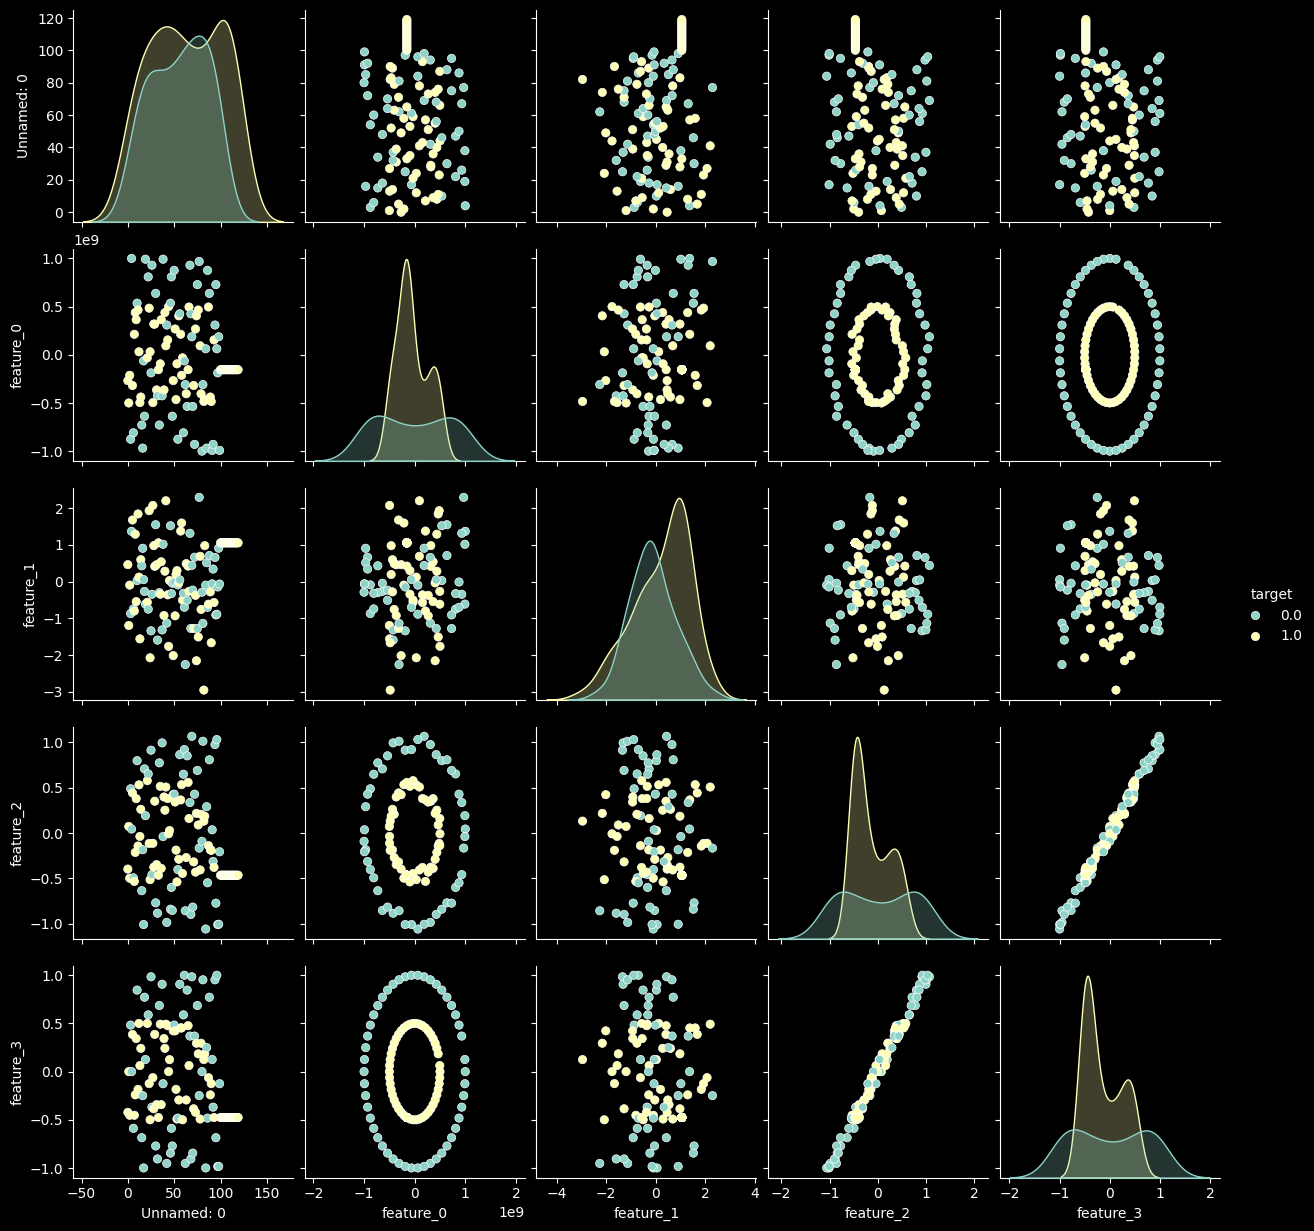

In [10]:
import seaborn as sns
sns.pairplot(df, hue='target')

<Figure size 600x500 with 0 Axes>

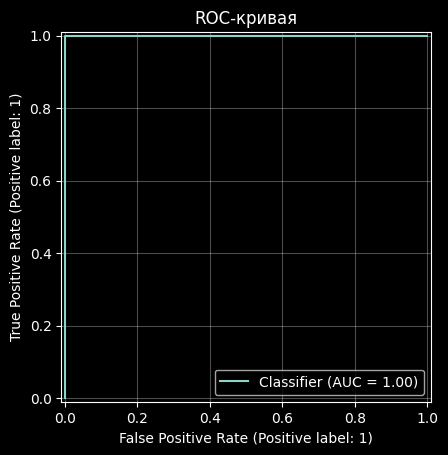

<Figure size 600x500 with 0 Axes>

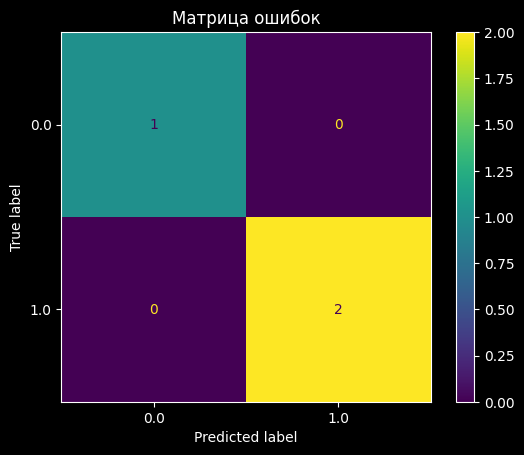

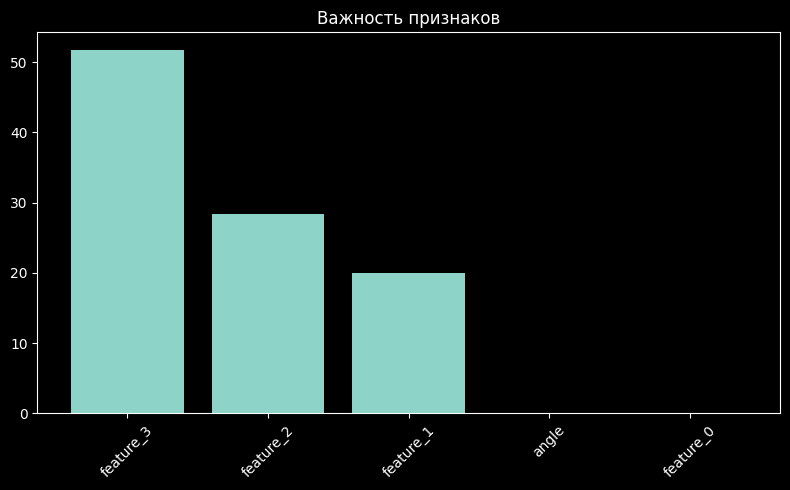

In [11]:
## Графики результатов
%matplotlib inline
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ROC-кривая
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC-кривая')
plt.grid(True, alpha=0.3)
plt.show()

# Матрица ошибок
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Матрица ошибок')
plt.show()

# Важность признаков
importances = model.get_feature_importance()
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 5))
plt.title("Важность признаков")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()